# Loading the packages

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random 
from collections import Counter



# Reading in the data

Our data are provided in a csv-format and we can use the read_csv inbuilt pandas function. This function converts our data in a dataframe

In [73]:
aviation_data=pd.read_csv("aviation.csv")
shipping_data=pd.read_csv("shipping.csv")

# by default the index is an integer number of range (1,...,n) rows.
# you can also explcitly assign an index with index_col="example"


There are a lot of options available for the read_csv function. By default this function expects the data to be seperated with comma, however, sometimes you need a different so-called seperator -> read_csv(sep=";") 

# Data cleaning and pre-preperation

First look on our data:

In [74]:
aviation_data.head()

,source_id,source_name,source_type,iso3_country,sector,subsector,start_time,end_time,lat,lon,...,other9,other9_def,other10,other10_def,created_date,modified_date,sector_id,reporting_entity,lat_lon,native_source_id
0,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-01-01 00:00:00,2021-01-31 00:00:00,12.5014,-70.015198,...,NaN,NaN,NaN,NaN,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,NaN,iata_AUA
1,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-02-01 00:00:00,2021-02-28 00:00:00,12.5014,-70.015198,...,NaN,NaN,NaN,NaN,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,NaN,iata_AUA
2,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-03-01 00:00:00,2021-03-31 00:00:00,12.5014,-70.015198,...,NaN,NaN,NaN,NaN,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,NaN,iata_AUA
3,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-04-01 00:00:00,2021-04-30 00:00:00,12.5014,-70.015198,...,NaN,NaN,NaN,NaN,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,NaN,iata_AUA
4,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-05-01 00:00:00,2021-05-31 00:00:00,12.5014,-70.015198,...,NaN,NaN,NaN,NaN,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,NaN,iata_AUA


As we can see the dataset contains several columns with NaN values. For a comprehensive overview we can use the pandas decribe() function

In [75]:
aviation_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 135420 entries, 0 to 135419
Data columns (total 47 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   source_id               135420 non-null  int64  
 1   source_name             135420 non-null  str    
 2   source_type             135420 non-null  str    
 3   iso3_country            135420 non-null  str    
 4   sector                  135420 non-null  str    
 5   subsector               135420 non-null  str    
 6   start_time              135420 non-null  str    
 7   end_time                135420 non-null  str    
 8   lat                     135420 non-null  float64
 9   lon                     135420 non-null  float64
 10  geometry_ref            0 non-null       float64
 11  gas                     135420 non-null  str    
 12  emissions_quantity      135420 non-null  float64
 13  temporal_granularity    135420 non-null  str    
 14  activity                135420 

We can now choose how we deal with the NaN-values. One convenient way is dropna()


In [76]:
# we want to remove the the whole columns, therefore we add the argument for the respective axis 
aviation_data_cleaned=aviation_data.dropna(axis="columns")
shipping_data_cleaned=shipping_data.dropna(axis="columns")

Note that if you deal with big data you often make use of functions and loops in order create pipelines:

In [77]:
def cleaning(dataset):
    return dataset.dropna(axis="columns")


def duplicate_cleaning(dataset):
    return dataset.drop_duplicates()


datasets = {
    "aviation_data": aviation_data,
    "shipping_data": shipping_data
}

methods = [cleaning, duplicate_cleaning]


for name, dataset in datasets.items():
    for method in methods:
        dataset = method(dataset)

    datasets[name] = dataset

In [78]:
#mapping am Ende für die Zuweisung nutzen von Flugzeugen oder Schiffen die nicht mehr genutzt werden sollen 



Next have a look again on the data type of the start and end times. We do want them to be in a datetime format. One way would be as follows:

In [ ]:
# one way could be:

aviation_data_cleaned["start_time"]=pd.to_datetime(aviation_data_cleaned["start_time"])

However, usually you work with different files and therefore loops and functions are recommended:

In [ ]:


def data_conversion(dataset):
    dataset["start_time"]=pd.to_datetime(dataset["start_time"])
    dataset["end_time"]=pd.to_datetime(dataset["end_time"])
    return dataset


data_list=[aviation_data_cleaned,shipping_data_cleaned]

for data in data_list:
    data_conversion(data)

In [80]:
aviation_data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 135420 entries, 0 to 135419
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   source_id               135420 non-null  int64         
 1   source_name             135420 non-null  str           
 2   source_type             135420 non-null  str           
 3   iso3_country            135420 non-null  str           
 4   sector                  135420 non-null  str           
 5   subsector               135420 non-null  str           
 6   start_time              135420 non-null  datetime64[us]
 7   end_time                135420 non-null  datetime64[us]
 8   lat                     135420 non-null  float64       
 9   lon                     135420 non-null  float64       
 10  gas                     135420 non-null  str           
 11  emissions_quantity      135420 non-null  float64       
 12  temporal_granularity    135420 non-null  

lets also create a new column for the start_time year

In [ ]:
def date_conversion(data):
    data["year"]=data["start_time"].dt.year
    return data


for data in data_list:
    date_conversion(data)


For now the data looks fine, no more NaN values and all everything in the right format. Lets get a first impression of some descriptive stats

In [82]:
aviation_data_cleaned

,source_id,source_name,source_type,iso3_country,sector,subsector,start_time,end_time,lat,lon,...,emissions_factor_units,capacity,capacity_units,capacity_factor,created_date,modified_date,sector_id,reporting_entity,native_source_id,year
0,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-01-01,2021-01-31,12.5014,-70.015198,...,t of CO2e_100yr per t of fuel,1590,flights,3.808106,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_AUA,2021
1,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-02-01,2021-02-28,12.5014,-70.015198,...,t of CO2e_100yr per t of fuel,1520,flights,3.699440,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_AUA,2021
2,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-03-01,2021-03-31,12.5014,-70.015198,...,t of CO2e_100yr per t of fuel,1768,flights,3.594831,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_AUA,2021
3,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-04-01,2021-04-30,12.5014,-70.015198,...,t of CO2e_100yr per t of fuel,1682,flights,3.925321,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_AUA,2021
4,3165649,Queen Beatrix International Airport,international,ABW,transportation,international-aviation,2021-05-01,2021-05-31,12.5014,-70.015198,...,t of CO2e_100yr per t of fuel,1725,flights,4.061021,2025-05-05 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_AUA,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135415,3169756,Victoria Falls International Airport,international,ZWE,transportation,international-aviation,2025-09-01,2025-09-30,-18.0959,25.839001,...,t of CO2e_100yr per t of fuel,773,flights,1.970598,2025-11-03 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_VFA,2025
135416,3169756,Victoria Falls International Airport,international,ZWE,transportation,international-aviation,2025-10-01,2025-10-31,-18.0959,25.839001,...,t of CO2e_100yr per t of fuel,791,flights,2.019090,2025-11-03 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_VFA,2025
135417,3169756,Victoria Falls International Airport,international,ZWE,transportation,international-aviation,2025-11-01,2025-11-30,-18.0959,25.839001,...,t of CO2e_100yr per t of fuel,645,flights,2.084272,2026-01-06 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_VFA,2025
135418,3169756,Victoria Falls International Airport,international,ZWE,transportation,international-aviation,2025-12-01,2025-12-31,-18.0959,25.839001,...,t of CO2e_100yr per t of fuel,549,flights,2.196215,2026-02-02 00:00:00,2026-03-06 18:10:58,64,climate-trace,iata_VFA,2025


In [83]:
aviation_data_cleaned.describe()

,source_id,start_time,end_time,lat,lon,emissions_quantity,activity,emissions_factor,capacity,capacity_factor,sector_id,year
count,1.354200e+05,135420,135420,135420.000000,135420.000000,1.354200e+05,135420.000000,1.354200e+05,135420.000000,135420.000000,135420.0,135420.000000
mean,4.781811e+06,2023-07-02 02:21:38.360655,2023-07-31 12:59:00.983606,27.805174,10.273544,1.777794e+04,5582.035904,3.184848e+00,794.238621,2.640764,64.0,2023.049180
min,8.268740e+05,2021-01-01 00:00:00,2021-01-31 00:00:00,-54.843300,-179.667007,0.000000e+00,0.000000,3.184848e+00,0.000000,0.000000,64.0,2021.000000
25%,3.166576e+06,2022-04-01 00:00:00,2022-04-30 00:00:00,13.898300,-61.427159,0.000000e+00,0.000000,3.184848e+00,0.000000,0.000000,64.0,2022.000000
50%,3.167826e+06,2023-07-01 00:00:00,2023-07-31 00:00:00,34.053749,14.687551,5.674604e+01,17.817505,3.184848e+00,10.000000,0.938763,64.0,2023.000000
75%,3.169110e+06,2024-10-01 00:00:00,2024-10-31 00:00:00,44.883974,55.675500,2.638393e+03,828.420547,3.184848e+00,259.000000,3.535523,64.0,2024.000000
max,5.112815e+07,2026-01-01 00:00:00,2026-01-31 00:00:00,78.246101,179.195999,1.868720e+06,586753.356177,3.184848e+00,43471.000000,78.992528,64.0,2026.000000
std,8.046154e+06,NaN,NaN,23.933280,75.547543,8.809461e+04,27660.538505,1.017911e-14,2833.385969,4.662863,0.0,1.453393


we are interested in the capacities and emission quantities in regrads to their geographical positions. Lets plot them... this will usually give you a certain feeling on the data 

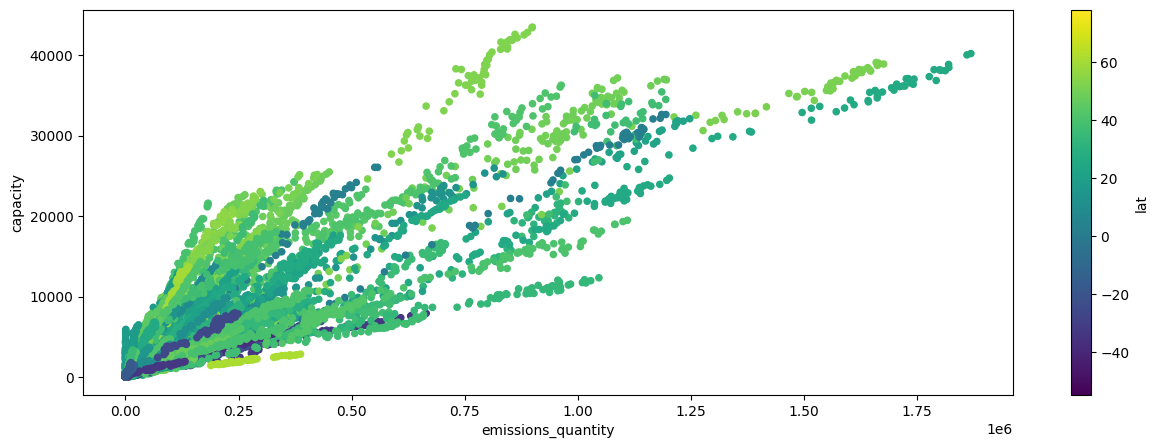

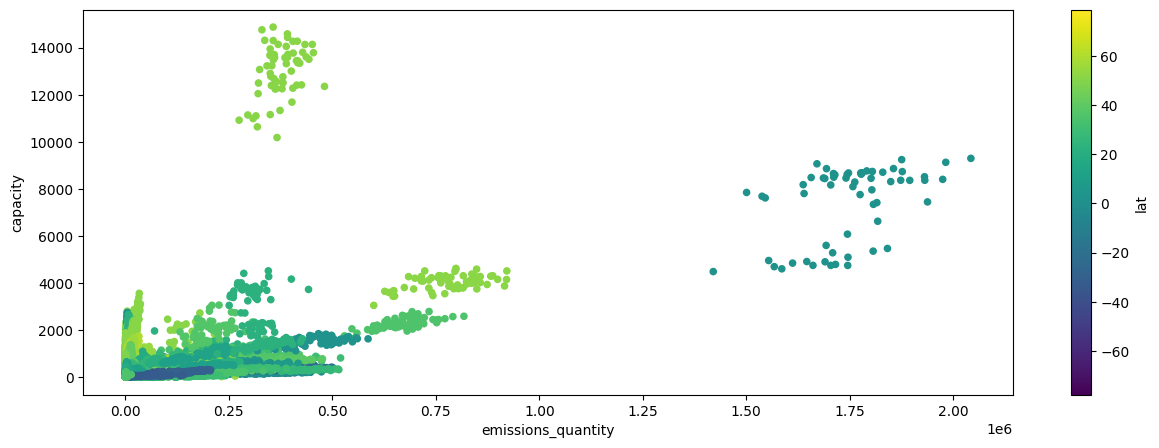

In [84]:

for data in data_list:
    data.plot("emissions_quantity","capacity",figsize=(15,5),kind="scatter",c="lat")


on first impressions we see in general a tendency that indicates growing emissions with more capacity. However, the shipping data might imply some clusters with very high emissions apart from midsize capacity. 

In [85]:
shipping_data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 531779 entries, 0 to 531778
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   source_id               531779 non-null  int64         
 1   source_name             531779 non-null  str           
 2   iso3_country            531779 non-null  str           
 3   sector                  531779 non-null  str           
 4   subsector               531779 non-null  str           
 5   start_time              531779 non-null  datetime64[us]
 6   end_time                531779 non-null  datetime64[us]
 7   lat                     531779 non-null  float64       
 8   lon                     531779 non-null  float64       
 9   gas                     531779 non-null  str           
 10  emissions_quantity      531779 non-null  float64       
 11  temporal_granularity    531779 non-null  str           
 12  activity                531779 non-null  

In [86]:
shipping_data_cleaned["other1"].value_counts()

other1
Norwegian Exclusive Economic Zone                                       39348
Chinese Exclusive Economic Zone                                         39307
United States Exclusive Economic Zone                                   35662
Indonesian Exclusive Economic Zone                                      28362
Japanese Exclusive Economic Zone                                        21962
                                                                        ...  
Australian Exclusive Economic Zone (Macquarie Island)                       1
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands)        1
Joint regime area Colombia / Dominican Republic                             1
Overlapping claim Glorioso Islands: France / Madagascar                     1
Palmyra Atoll Exclusive Economic Zone                                       1
Name: count, Length: 243, dtype: int64

## Discretization and Classification

In order to analyse the shipping data cluster more in detail, we first discretize them into latitute groups and assign them names

In [87]:
bins = [-90, -60, -30, 0, 30, 60, 90]

shipping_data_cleaned["bin_cat"]=pd.cut(shipping_data_cleaned["lat"],bins,labels=[
        "Polar South",
        "Temperate South",
        "Tropical South",
        "Tropical North",
        "Temperate North",
        "Polar North"
    ])
shipping_data_cleaned

,source_id,source_name,iso3_country,sector,subsector,start_time,end_time,lat,lon,gas,...,other1,other1_def,other2_def,other10_def,created_date,modified_date,reporting_entity,native_source_id,year,bin_cat
0,2787590,Oranjestad,ABW,transportation,international-shipping,2021-01-01,2021-01-31,12.500898,-70.019501,co2e_100yr,...,Aruban Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2024-08-20 00:00:00,2026-03-06 01:54:05,climate-trace,ABW_2710736128,2021,Tropical North
1,2787590,Oranjestad,ABW,transportation,international-shipping,2021-02-01,2021-02-28,12.500898,-70.019501,co2e_100yr,...,Aruban Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2024-08-20 00:00:00,2026-03-06 01:54:05,climate-trace,ABW_2710736128,2021,Tropical North
2,2787590,Oranjestad,ABW,transportation,international-shipping,2021-03-01,2021-03-31,12.500898,-70.019501,co2e_100yr,...,Aruban Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2024-08-20 00:00:00,2026-03-06 01:54:05,climate-trace,ABW_2710736128,2021,Tropical North
3,2787590,Oranjestad,ABW,transportation,international-shipping,2021-04-01,2021-04-30,12.500898,-70.019501,co2e_100yr,...,Aruban Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2024-08-20 00:00:00,2026-03-06 01:54:05,climate-trace,ABW_2710736128,2021,Tropical North
4,2787590,Oranjestad,ABW,transportation,international-shipping,2021-05-01,2021-05-31,12.500898,-70.019501,co2e_100yr,...,Aruban Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2024-08-20 00:00:00,2026-03-06 01:54:05,climate-trace,ABW_2710736128,2021,Tropical North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531774,2855359,Xeros,ZNC,transportation,international-shipping,2025-09-01,2025-09-30,35.133293,32.833294,co2e_100yr,...,Cypriote Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2025-10-17 00:00:00,2026-03-09 04:29:10.953708,climate-trace,CYP_2391255381,2025,Temperate North
531775,2855359,Xeros,ZNC,transportation,international-shipping,2025-10-01,2025-10-31,35.133293,32.833294,co2e_100yr,...,Cypriote Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2025-11-17 00:00:00,2026-03-09 04:29:10.953708,climate-trace,CYP_2391255381,2025,Temperate North
531776,2855359,Xeros,ZNC,transportation,international-shipping,2025-11-01,2025-11-30,35.133293,32.833294,co2e_100yr,...,Cypriote Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2025-12-12 00:00:00,2026-03-09 04:29:10.953708,climate-trace,CYP_2391255381,2025,Temperate North
531777,2855359,Xeros,ZNC,transportation,international-shipping,2025-12-01,2025-12-31,35.133293,32.833294,co2e_100yr,...,Cypriote Exclusive Economic Zone,economic_zone,CO2_emissions_factor,ship dead weight,2026-01-13 00:00:00,2026-03-09 04:29:10.953708,climate-trace,CYP_2391255381,2025,Temperate North


in the data we have a column called: other1. It contains information on the respective economic zones. We will rename the column and then analyse which ecnomic zone outliers here in terms of emissions

In [88]:
shipping_data_cleaned=shipping_data_cleaned.rename(columns={"other1":"economic_zone"})

The data are cleaned and pre-procecced. We can now continue to further process them in order to get some value in terms of useful informations out of them 

# Data processing 